##import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## read data

In [2]:
df=pd.read_csv(r"/content/employee_promotion_dataset_filled.csv")

In [3]:
df.head()

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,...,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,promotion,job_satisfaction
0,56.0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,...,Master,Data Scientist,Finance,Tanta,Startup,Onsite,Married,0.0,0,NaN
1,46.0,18372.0,9.0,41.0,2.60,29.0,19.0,NaN,58.0,9.0,...,Bachelor,NaN,Operations,Tanta,SME,Remote,Married,0.0,0,Medium
2,32.0,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,...,Master,Data Scientist,Operations,Mansoura,SME,Onsite,Married,0.0,0,High
3,60.0,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,...,High School,HR,Operations,Alexandria,Enterprise,Remote,Single,1.0,0,Medium
4,NaN,29868.0,39.0,NaN,3.29,NaN,NaN,4.4,14.0,13.0,...,PhD,HR,Operations,Mansoura,Startup,Hybrid,Married,1.0,0,Low


## show info of data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     13822 non-null  float64
 1   salary                  13747 non-null  float64
 2   experience_years        13824 non-null  float64
 3   working_hours_per_week  13795 non-null  float64
 4   performance_score       13817 non-null  float64
 5   projects_completed      13769 non-null  float64
 6   overtime_hours          13804 non-null  float64
 7   distance_from_home_km   13770 non-null  float64
 8   training_hours          13758 non-null  float64
 9   absent_days             13772 non-null  float64
 10  gender                  13816 non-null  object 
 11  education_level         13820 non-null  object 
 12  job_role                13772 non-null  object 
 13  department              13811 non-null  object 
 14  city                    13817 non-null

In [5]:
df.shape

(15000, 21)

In [6]:
df.dropna(how='all',inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     13822 non-null  float64
 1   salary                  13747 non-null  float64
 2   experience_years        13824 non-null  float64
 3   working_hours_per_week  13795 non-null  float64
 4   performance_score       13817 non-null  float64
 5   projects_completed      13769 non-null  float64
 6   overtime_hours          13804 non-null  float64
 7   distance_from_home_km   13770 non-null  float64
 8   training_hours          13758 non-null  float64
 9   absent_days             13772 non-null  float64
 10  gender                  13816 non-null  object 
 11  education_level         13820 non-null  object 
 12  job_role                13772 non-null  object 
 13  department              13811 non-null  object 
 14  city                    13817 non-null

In [8]:
df.shape

(15000, 21)

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
salary,1253
training_hours,1242
projects_completed,1231
distance_from_home_km,1230
absent_days,1228
job_role,1228
marital_status,1210
work_mode,1208
working_hours_per_week,1205
job_satisfaction,1196


In [10]:
df.select_dtypes(include='number').columns

Index(['age', 'salary', 'experience_years', 'working_hours_per_week',
       'performance_score', 'projects_completed', 'overtime_hours',
       'distance_from_home_km', 'training_hours', 'absent_days',
       'has_certifications', 'promotion'],
      dtype='object')

In [11]:
cont_cols = [
    'experience_years',
    'working_hours_per_week',
    'performance_score',
    'distance_from_home_km',
    'training_hours',
    'overtime_hours',
    'salary',
    'age'
]


## missing value

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

iter_imputer = IterativeImputer(
    estimator=DecisionTreeRegressor(),
    max_iter=20,
    random_state=42
)

df[cont_cols] = iter_imputer.fit_transform(df[cont_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [13]:


df.isnull().sum().sort_values(ascending=False)

,0
projects_completed,1231
absent_days,1228
job_role,1228
marital_status,1210
work_mode,1208
job_satisfaction,1196
company_type,1195
department,1189
gender,1184
city,1183


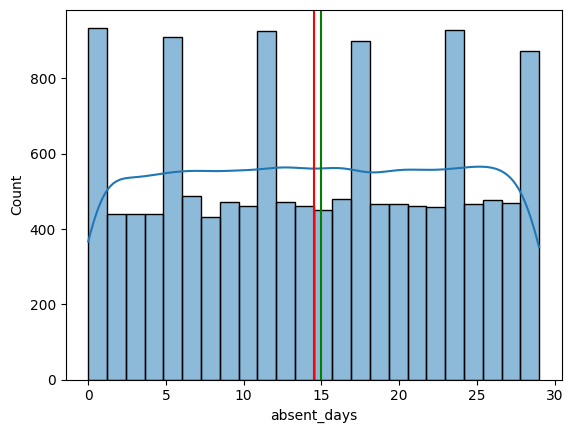

In [14]:
sns.histplot(data=df,x='absent_days',kde=True)
plt.axvline(df.absent_days.mean(),color='r')
plt.axvline(df.absent_days.median(),color='g')

In [15]:


fig = px.histogram(df,x="promotion",color="promotion",title="Promotion Class Distribution",
    text_auto=True
)
fig.show()


In [16]:
fig = px.violin( df, x="promotion", y="salary", box=True,
    points="all",
    title="Salary Distribution by Promotion"
)
fig.show()


In [17]:

df.select_dtypes(include='object').columns

Index(['gender', 'education_level', 'job_role', 'department', 'city',
       'company_type', 'work_mode', 'marital_status', 'job_satisfaction'],
      dtype='object')

In [18]:
median=['projects_completed','absent_days']
mode=['gender', 'education_level', 'job_role', 'department', 'city',
       'company_type', 'work_mode', 'marital_status', 'job_satisfaction']

## impute missing value

In [19]:
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy='median')
for col in median:
  df[col]=impute.fit_transform(df[[col]])

In [20]:
df.isnull().sum()

,0
age,0
salary,0
experience_years,0
working_hours_per_week,0
performance_score,0
projects_completed,0
overtime_hours,0
distance_from_home_km,0
training_hours,0
absent_days,0


In [21]:
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy='most_frequent')
for col in mode:
  df[[col]]=impute.fit_transform(df[[col]])

In [22]:
df.isnull().sum()

,0
age,0
salary,0
experience_years,0
working_hours_per_week,0
performance_score,0
projects_completed,0
overtime_hours,0
distance_from_home_km,0
training_hours,0
absent_days,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     15000 non-null  float64
 1   salary                  15000 non-null  float64
 2   experience_years        15000 non-null  float64
 3   working_hours_per_week  15000 non-null  float64
 4   performance_score       15000 non-null  float64
 5   projects_completed      15000 non-null  float64
 6   overtime_hours          15000 non-null  float64
 7   distance_from_home_km   15000 non-null  float64
 8   training_hours          15000 non-null  float64
 9   absent_days             15000 non-null  float64
 10  gender                  15000 non-null  object 
 11  education_level         15000 non-null  object 
 12  job_role                15000 non-null  object 
 13  department              15000 non-null  object 
 14  city                    15000 non-null

In [24]:
df.head(20)

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,...,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,promotion,job_satisfaction
0,56.0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,...,Master,Data Scientist,Finance,Tanta,Startup,Onsite,Married,0.0,0,Medium
1,46.0,18372.0,9.0,41.0,2.60,29.0,19.0,42.9,58.0,9.0,...,Bachelor,Engineer,Operations,Tanta,SME,Remote,Married,0.0,0,Medium
2,32.0,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,...,Master,Data Scientist,Operations,Mansoura,SME,Onsite,Married,0.0,0,High
3,60.0,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,...,High School,HR,Operations,Alexandria,Enterprise,Remote,Single,1.0,0,Medium
4,30.0,29868.0,39.0,58.0,3.29,25.0,16.0,4.4,14.0,13.0,...,PhD,HR,Operations,Mansoura,Startup,Hybrid,Married,1.0,0,Low
5,38.0,31475.0,22.0,30.0,4.96,32.0,23.0,2.1,130.0,23.0,...,Master,Engineer,Operations,Alexandria,SME,Remote,Married,1.0,1,Medium
6,56.0,5433.0,39.0,26.0,3.14,4.0,3.0,23.5,194.0,13.0,...,PhD,Data Scientist,HR,Cairo,Startup,Onsite,Married,0.0,0,Medium
7,36.0,13998.0,9.0,45.0,4.95,39.0,0.0,10.9,13.0,12.0,...,Bachelor,Sales,IT,Alexandria,Enterprise,Onsite,Single,1.0,1,High
8,40.0,34133.0,9.0,58.0,3.99,41.0,1.0,47.0,138.0,1.0,...,Master,Engineer,IT,Giza,Enterprise,Remote,Married,1.0,1,Medium
9,28.0,37069.0,9.0,34.0,1.48,2.0,3.0,32.4,74.0,19.0,...,High School,HR,Finance,Tanta,SME,Onsite,Single,0.0,0,Low


In [25]:
bin_cols=['has_certifications']

In [26]:

from sklearn.impute import KNNImputer
impute=KNNImputer(n_neighbors=15)
df[bin_cols] = impute.fit_transform(df[bin_cols])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     15000 non-null  float64
 1   salary                  15000 non-null  float64
 2   experience_years        15000 non-null  float64
 3   working_hours_per_week  15000 non-null  float64
 4   performance_score       15000 non-null  float64
 5   projects_completed      15000 non-null  float64
 6   overtime_hours          15000 non-null  float64
 7   distance_from_home_km   15000 non-null  float64
 8   training_hours          15000 non-null  float64
 9   absent_days             15000 non-null  float64
 10  gender                  15000 non-null  object 
 11  education_level         15000 non-null  object 
 12  job_role                15000 non-null  object 
 13  department              15000 non-null  object 
 14  city                    15000 non-null

In [28]:
df.isnull().sum().sum()

np.int64(0)

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
corr=df.corr(numeric_only=True)

<Axes: >

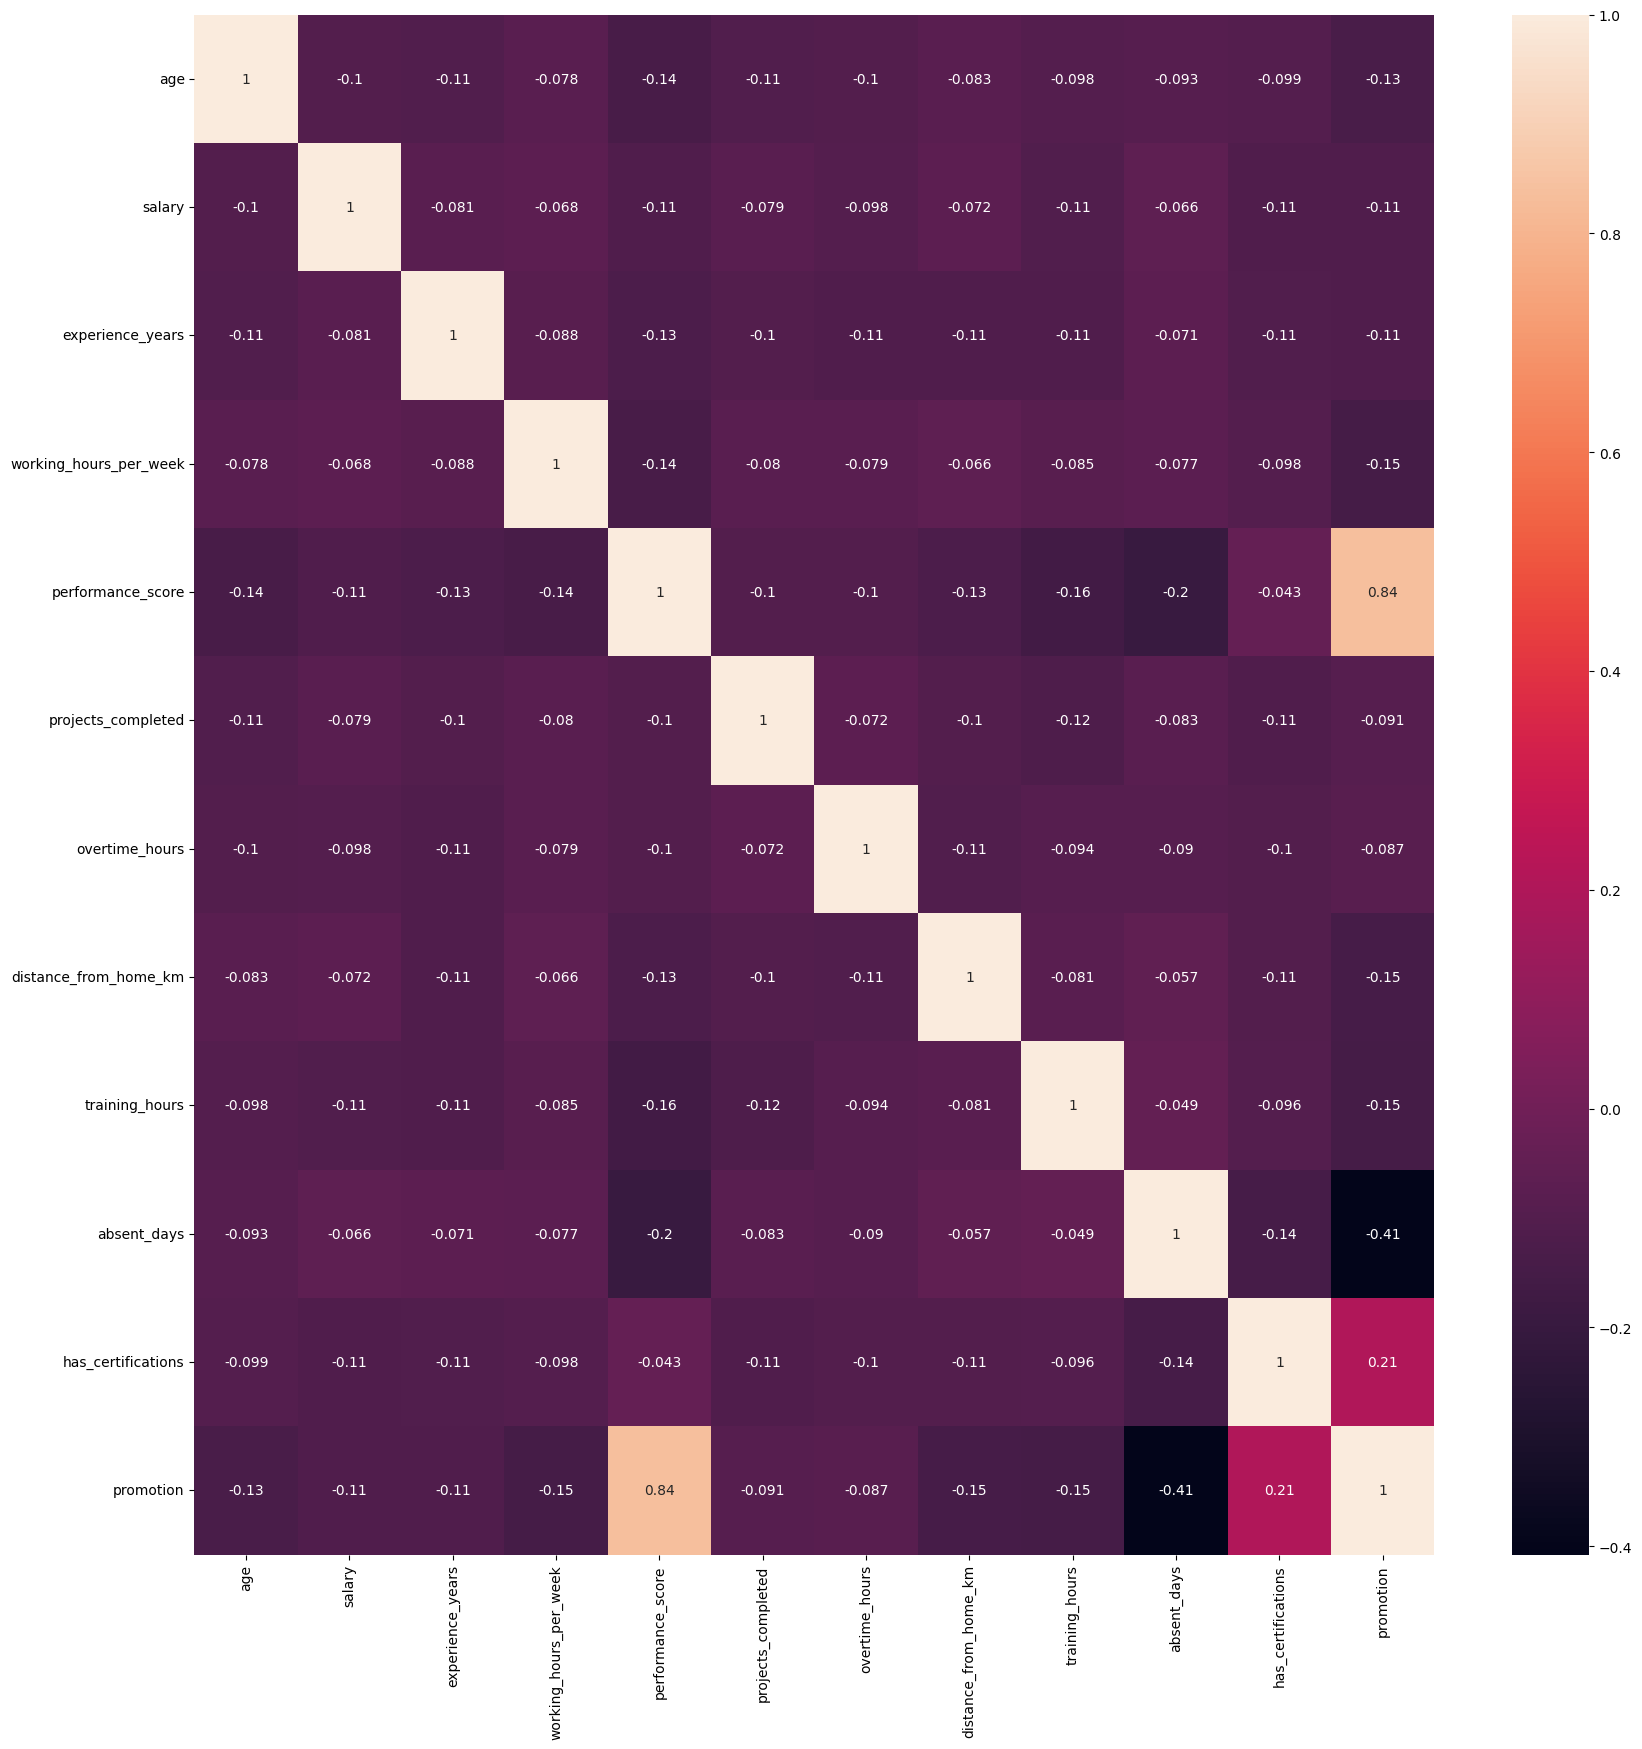

In [31]:
plt.figure(figsize=(20,20))
sns.heatmap(corr.corr(),annot=True)

In [32]:
df.describe()

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,has_certifications,promotion
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000
mean,41.061467,21410.562600,19.577733,39.527067,2.999700,24.651133,14.535000,25.487427,100.001333,14.557067,0.492452,0.21240
std,13.494200,10541.530251,11.572609,11.592208,1.150787,13.836302,8.717078,14.308315,57.579037,8.269436,0.480326,0.40902
min,18.000000,3002.000000,0.000000,20.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,30.000000,12452.000000,9.000000,30.000000,2.020000,13.000000,7.000000,12.900000,50.000000,8.000000,0.000000,0.00000
50%,41.000000,21317.000000,20.000000,40.000000,3.000000,25.000000,14.000000,25.600000,100.000000,15.000000,0.492452,0.00000
75%,53.000000,30394.000000,29.000000,49.000000,4.000000,36.000000,22.000000,38.000000,150.000000,21.000000,1.000000,0.00000
max,64.000000,39994.000000,39.000000,59.000000,5.000000,49.000000,29.000000,50.000000,199.000000,29.000000,1.000000,1.00000


In [33]:
px.box(data_frame=df,x='salary')

<Axes: xlabel='salary', ylabel='Count'>

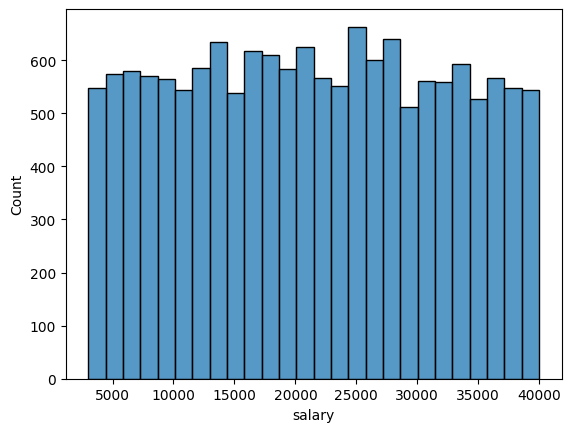

In [34]:
sns.histplot(data=df,x='salary')

## visualization

## promotion by score

Text(0.5, 1.0, 'Performance Score vs Promotion')

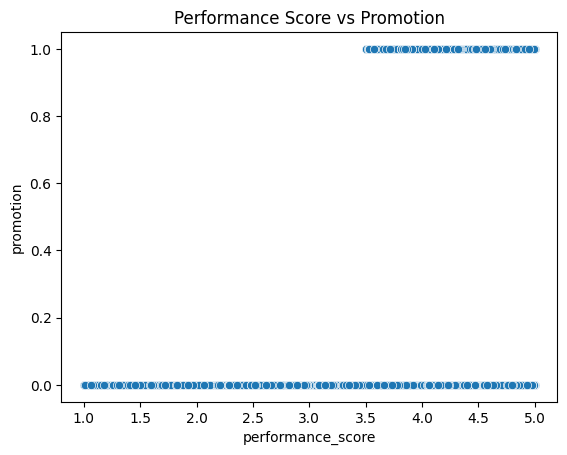

In [35]:

plt.figure()
sns.scatterplot( data=df,x='performance_score',y='promotion'
)
plt.title('Performance Score vs Promotion')



## relationship promotin by experiance

Text(0.5, 1.0, 'Experience Years vs Promotion')

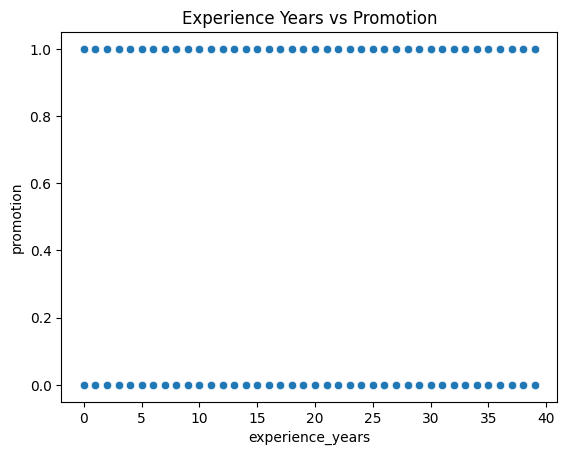

In [36]:
sns.scatterplot(data=df,x='experience_years',y='promotion')
plt.title('Experience Years vs Promotion')


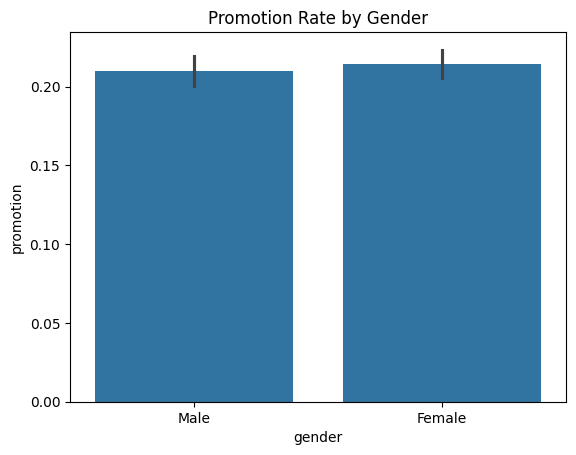

In [37]:
sns.barplot( data=df,x='gender', y='promotion')
plt.title('Promotion Rate by Gender')
plt.show()


Text(0.5, 1.0, 'Promotion Rate by Education Level')

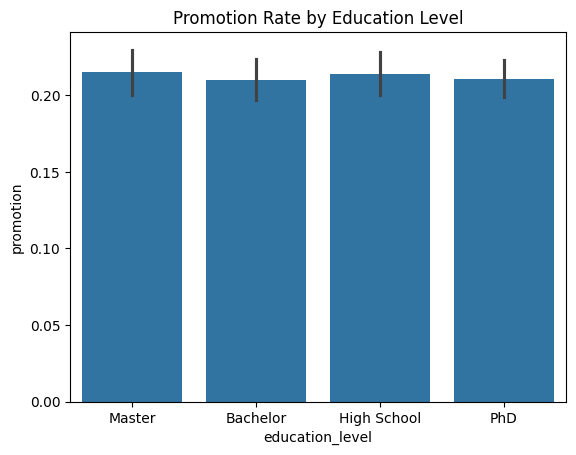

In [38]:
sns.barplot( data=df, x='education_level', y='promotion')
plt.title('Promotion Rate by Education Level')


Text(0.5, 1.0, 'Promotion Rate by Job Role')

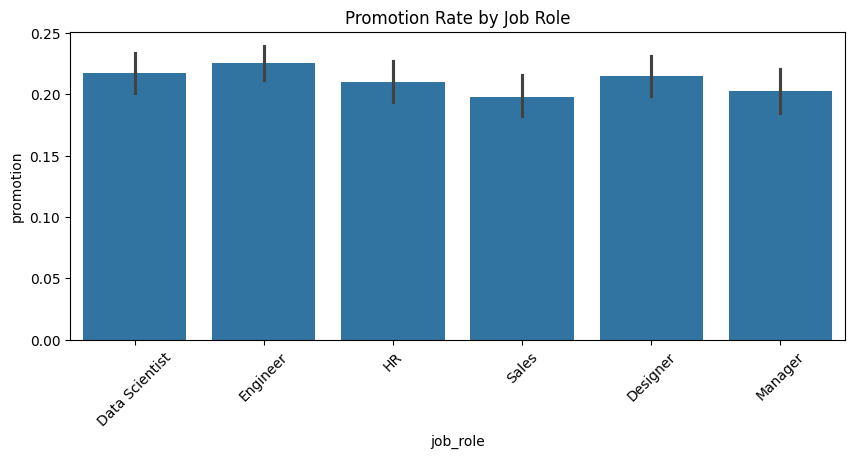

In [39]:

plt.figure(figsize=(10,4))
sns.barplot(data=df,x='job_role',y='promotion')
plt.xticks(rotation=45)
plt.title('Promotion Rate by Job Role')



Text(0.5, 1.0, 'Promotion Trend over Experience')

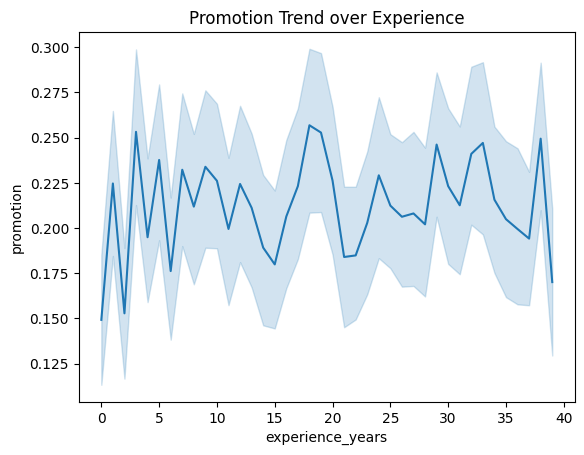

In [40]:



sns.lineplot( data=df, x='experience_years', y='promotion')
plt.title('Promotion Trend over Experience')


Text(0.5, 1.0, 'Promotion Trend over training_hours')

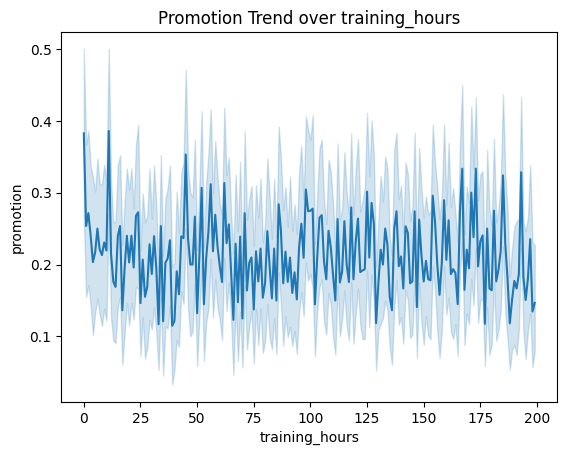

In [41]:
sns.lineplot( data=df, x='training_hours', y='promotion')
plt.title('Promotion Trend over training_hours')

Text(0.5, 1.0, 'Performance Distribution by Promotion')

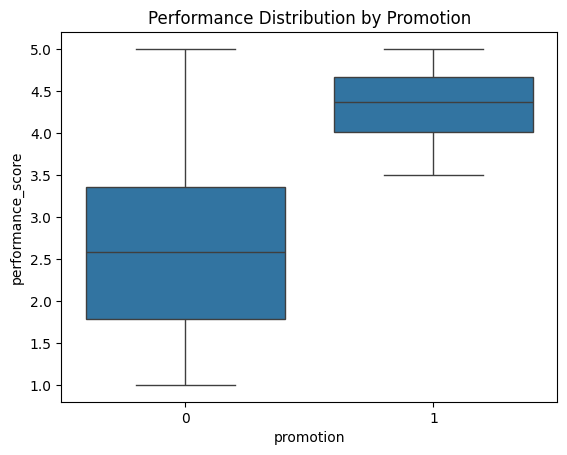

In [42]:

sns.boxplot( data=df,x='promotion',y='performance_score')
plt.title('Performance Distribution by Promotion')


In [43]:
fig = px.scatter_3d(df,x="experience_years",y="performance_score",z="training_hours",color="promotion",
    title="3D View: Experience vs Performance vs Training"
)
fig.show()


In [44]:
fig = px.bar(df, x="has_certifications", y="promotion",
    title="Effect of Certifications on Promotion"
)
fig.show()


In [45]:
df.shape

(15000, 21)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     15000 non-null  float64
 1   salary                  15000 non-null  float64
 2   experience_years        15000 non-null  float64
 3   working_hours_per_week  15000 non-null  float64
 4   performance_score       15000 non-null  float64
 5   projects_completed      15000 non-null  float64
 6   overtime_hours          15000 non-null  float64
 7   distance_from_home_km   15000 non-null  float64
 8   training_hours          15000 non-null  float64
 9   absent_days             15000 non-null  float64
 10  gender                  15000 non-null  object 
 11  education_level         15000 non-null  object 
 12  job_role                15000 non-null  object 
 13  department              15000 non-null  object 
 14  city                    15000 non-null

## drop columns

In [47]:
df.drop('age',axis=1,inplace=True)

In [48]:
df.drop('city',axis=1,inplace=True)

In [49]:
df.shape

(15000, 19)

In [50]:
df['job_role'].nunique()

6

# labels=[job_role',
# one hot=[gender,education_level,,company_type,marital_status,has_certifications,job_satisfaction

In [51]:
df.select_dtypes('object').columns

Index(['gender', 'education_level', 'job_role', 'department', 'company_type',
       'work_mode', 'marital_status', 'job_satisfaction'],
      dtype='object')

## encoding by one hot encoding

In [52]:
df.columns = df.columns.str.strip()

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns detected:")
print(categorical_cols)



Categorical columns detected:
['gender', 'education_level', 'job_role', 'department', 'company_type', 'work_mode', 'marital_status', 'job_satisfaction']


In [53]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import pickle
import os

os.makedirs("encoders", exist_ok=True)

df_encoded = df.copy()

for col in categorical_cols:
    print(f" Encoding -> {col}")

    ohe = OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    )

    encoded = ohe.fit_transform(df_encoded[[col]])

    new_cols = ohe.get_feature_names_out([col])

    encoded_df = pd.DataFrame(
        encoded,
        columns=new_cols,
        index=df_encoded.index
    )

    df_encoded.drop(columns=[col], inplace=True)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)

    with open(f'encoders/{col}_ohe.pkl', 'wb') as f:
        pickle.dump(ohe, f)



df = df_encoded.copy()


 Encoding -> gender
 Encoding -> education_level
 Encoding -> job_role
 Encoding -> department
 Encoding -> company_type
 Encoding -> work_mode
 Encoding -> marital_status
 Encoding -> job_satisfaction


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## save encoding

In [56]:
df.shape

(15000, 32)

In [57]:
df.head()

,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,has_certifications,...,department_IT,department_Marketing,department_Operations,company_type_SME,company_type_Startup,work_mode_Onsite,work_mode_Remote,marital_status_Single,job_satisfaction_Low,job_satisfaction_Medium
0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,18372.0,9.0,41.0,2.60,29.0,19.0,42.9,58.0,9.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,29868.0,39.0,58.0,3.29,25.0,16.0,4.4,14.0,13.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   salary                       15000 non-null  float64
 1   experience_years             15000 non-null  float64
 2   working_hours_per_week       15000 non-null  float64
 3   performance_score            15000 non-null  float64
 4   projects_completed           15000 non-null  float64
 5   overtime_hours               15000 non-null  float64
 6   distance_from_home_km        15000 non-null  float64
 7   training_hours               15000 non-null  float64
 8   absent_days                  15000 non-null  float64
 9   has_certifications           15000 non-null  float64
 10  promotion                    15000 non-null  int64  
 11  gender_Male                  15000 non-null  float64
 12  education_level_High School  15000 non-null  float64
 13  education_level_

##**split data**

In [59]:

x=df.drop('promotion',axis=1)
y=df['promotion']

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,
                                                 shuffle=True,random_state=42,stratify=y)

##**scaling by standard scaler**

In [61]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)








##**save scaleing**

In [62]:


pickle.dump(scaler,open("standard_scaler.pkl","wb"))

##**feature selection to important columns**

In [63]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(x_train, y_train)
X_test_selected  = selector.transform(x_test)


In [64]:


import pickle

with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)

with open("X_selected.pkl", "wb") as f:
    pickle.dump((X_train_selected, X_test_selected), f)


In [65]:
X_train_selected


array([[ 0.38106822,  0.96325054,  1.76203302, ..., -0.79945002,
        -0.66180573, -0.80155201],
       [-1.55150816,  0.95455932,  0.0290811 , ..., -0.79945002,
        -0.66180573,  1.24757968],
       [ 1.22412955, -0.20137349,  1.4732077 , ...,  1.25085993,
         1.51101745, -0.80155201],
       ...,
       [ 0.41159057, -1.09656958,  0.0290811 , ...,  1.25085993,
        -0.66180573,  1.24757968],
       [-0.02093572,  0.41570342,  0.89555706, ...,  1.25085993,
         1.51101745, -0.80155201],
       [ 0.91871651, -1.17479059,  0.0290811 , ...,  1.25085993,
        -0.66180573,  1.24757968]])

In [66]:
selector.get_feature_names_out()

array(['x0', 'x3', 'x4', 'x5', 'x8', 'x9', 'x10', 'x13', 'x15', 'x17',
       'x18', 'x23', 'x25', 'x29', 'x30'], dtype=object)

In [67]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


## models

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB,CategoricalNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import  HistGradientBoostingClassifier
import xgboost as xgb
from xgboost import  XGBClassifier
from catboost import  CatBoostClassifier
import lightgbm as lgb
from lightgbm import  LGBMClassifier








/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning:

Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.



In [69]:
models={
    "logistic regression":LogisticRegression(),
    "GaussianNB":GaussianNB(),
    "BernoulliNB":BernoulliNB(),
    "knn" : KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=1),
    "svm":SVC(kernel="linear",C=150,gamma=5,probability=True),
    "Decision Tree":DecisionTreeClassifier(criterion='entropy',max_depth=15),
    "Random Forest":RandomForestClassifier(n_estimators=70,criterion='entropy',max_depth=20),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=130, random_state=42),
  #  "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',max_depth=10),n_estimators=50, random_state=42),
  #  "ada bosting":AdaBoostClassifier(n_estimators=60,random_state=42),
  #  "Gradient boosting":GradientBoostingClassifier(n_estimators=60,learning_rate=0.1,random_state=42),
  #  "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42),
  #  "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
  #  "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

}

In [70]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score ,confusion_matrix,classification_report,roc_curve,auc
from sklearn.metrics import precision_recall_curve, average_precision_score

[[2234  129]
 [ 150  487]]


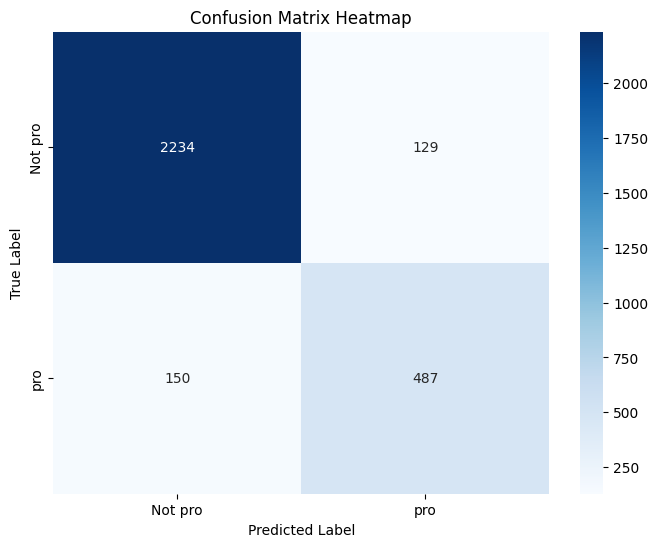

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      2363
           1       0.79      0.76      0.78       637

    accuracy                           0.91      3000
   macro avg       0.86      0.85      0.86      3000
weighted avg       0.91      0.91      0.91      3000



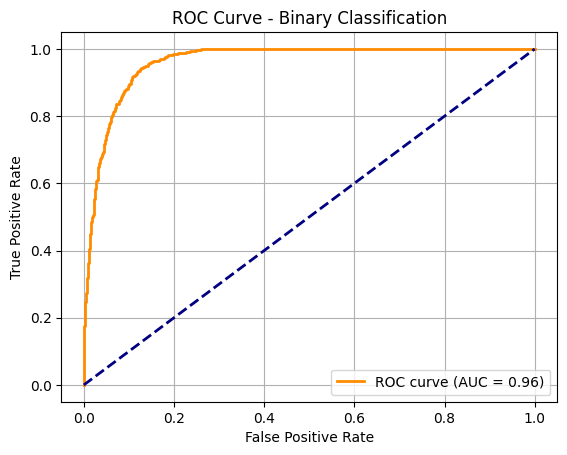

Average Precision (AP): 0.857


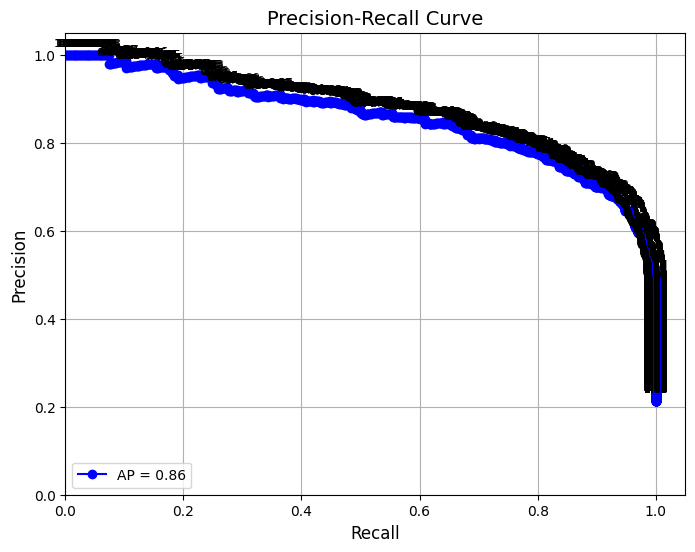

[[2181  182]
 [ 115  522]]


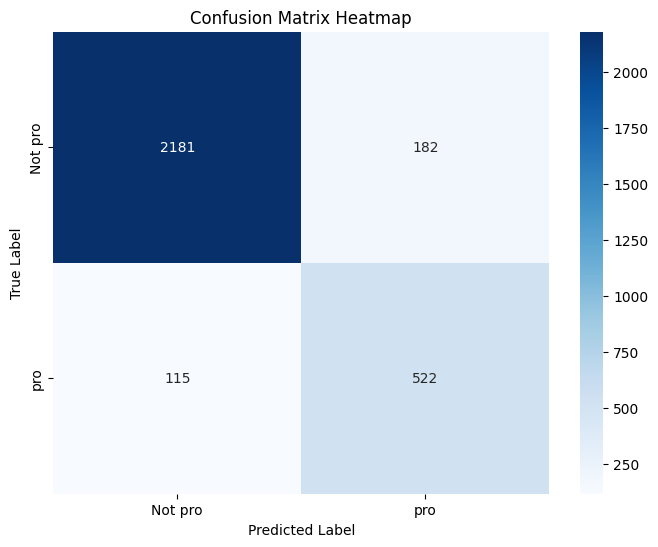

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2363
           1       0.74      0.82      0.78       637

    accuracy                           0.90      3000
   macro avg       0.85      0.87      0.86      3000
weighted avg       0.91      0.90      0.90      3000



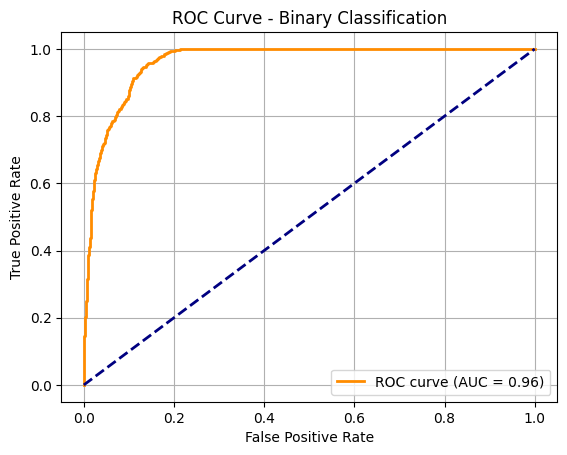

Average Precision (AP): 0.857


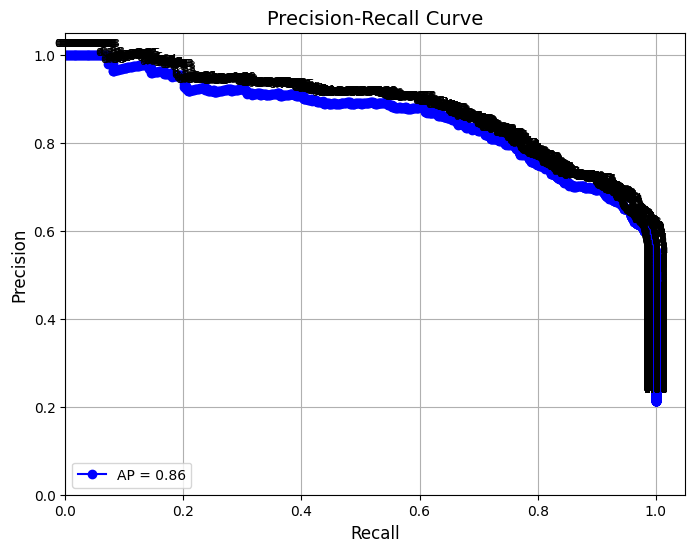

[[2248  115]
 [ 411  226]]


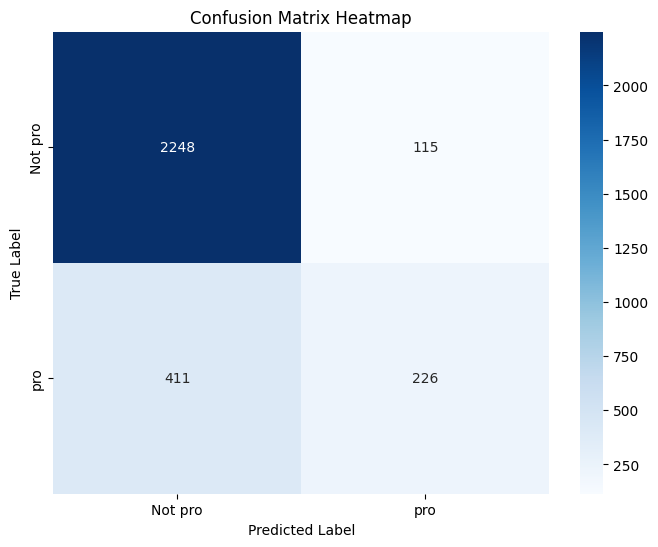

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2363
           1       0.66      0.35      0.46       637

    accuracy                           0.82      3000
   macro avg       0.75      0.65      0.68      3000
weighted avg       0.81      0.82      0.80      3000



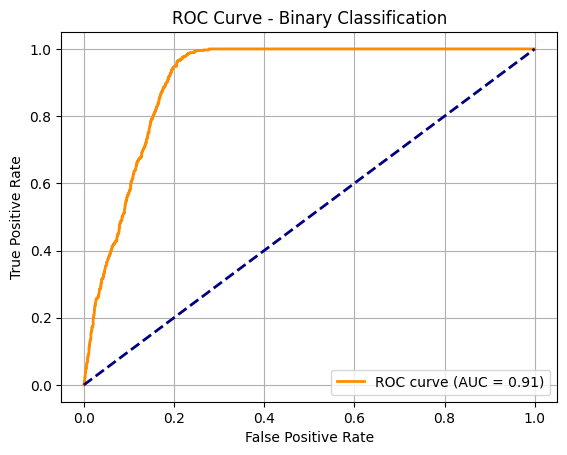

Average Precision (AP): 0.633


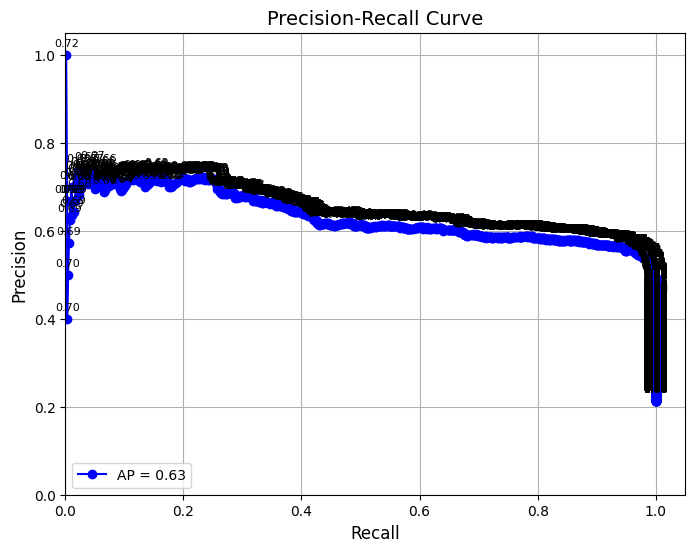

[[2261  102]
 [ 242  395]]


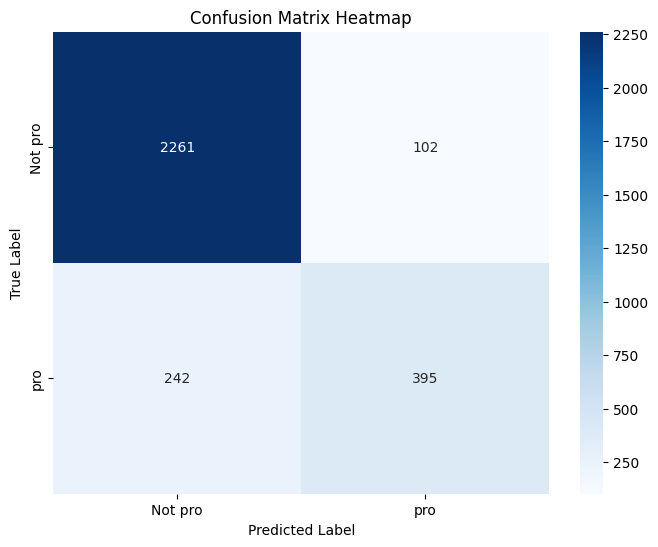

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      2363
           1       0.79      0.62      0.70       637

    accuracy                           0.89      3000
   macro avg       0.85      0.79      0.81      3000
weighted avg       0.88      0.89      0.88      3000



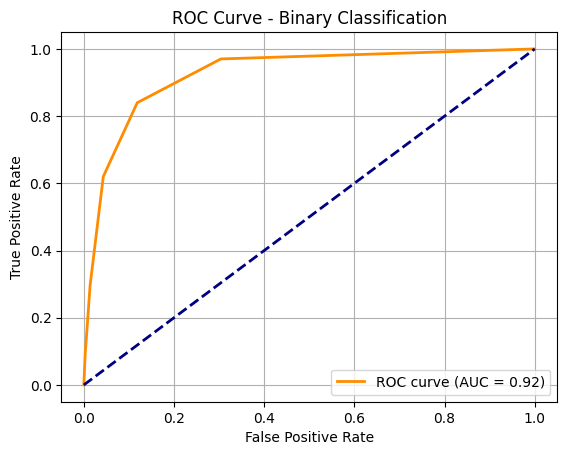

Average Precision (AP): 0.724


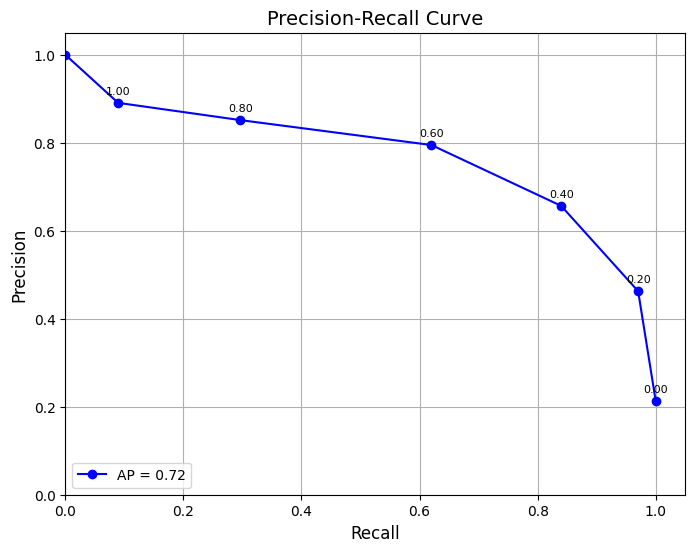

[[2233  130]
 [ 138  499]]


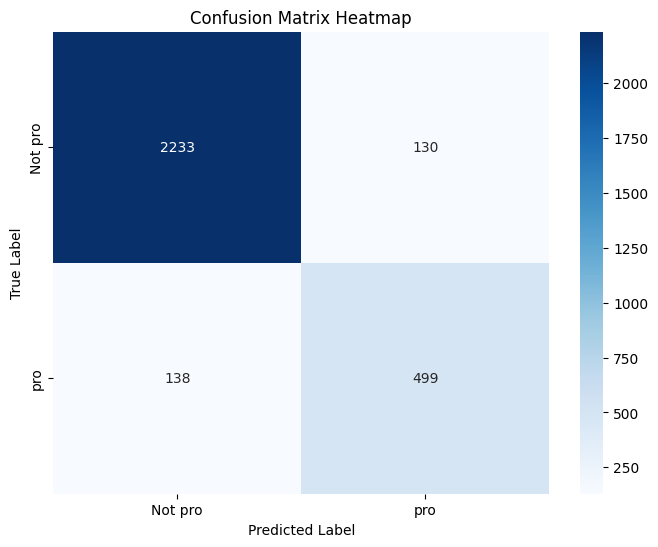

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2363
           1       0.79      0.78      0.79       637

    accuracy                           0.91      3000
   macro avg       0.87      0.86      0.87      3000
weighted avg       0.91      0.91      0.91      3000



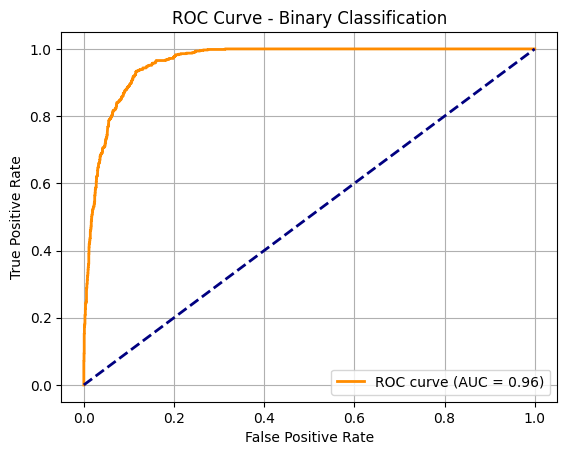

Average Precision (AP): 0.857


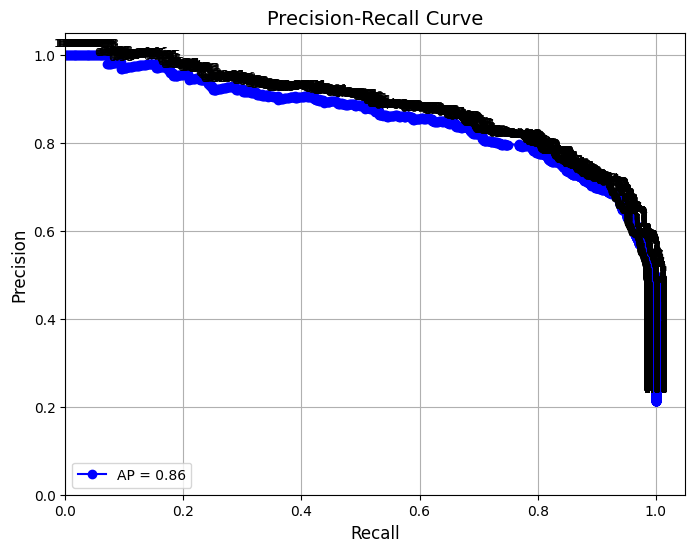

[[2312   51]
 [  50  587]]


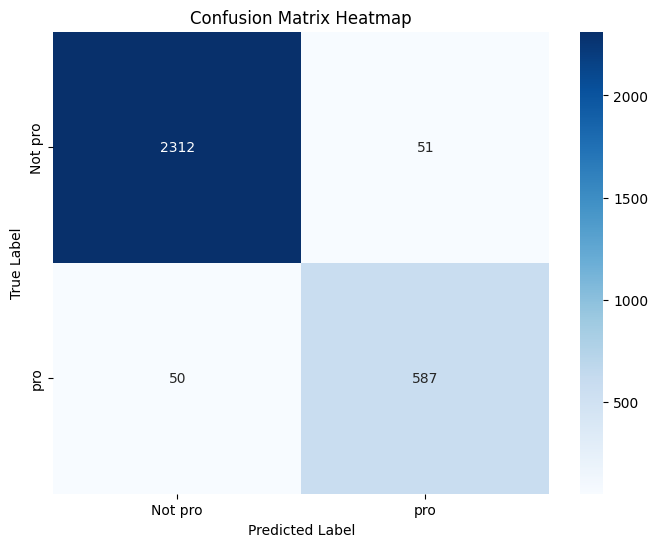

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2363
           1       0.92      0.92      0.92       637

    accuracy                           0.97      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.97      0.97      0.97      3000



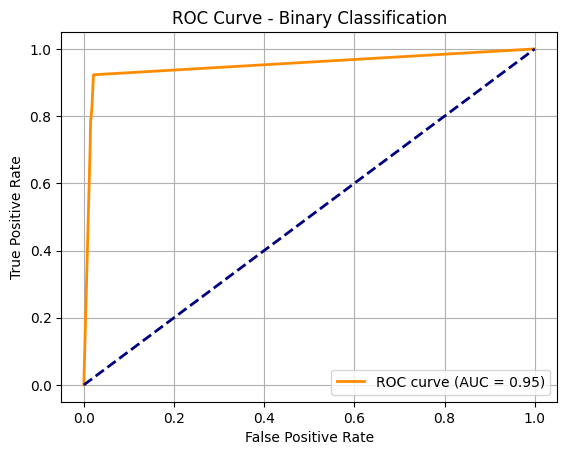

Average Precision (AP): 0.875


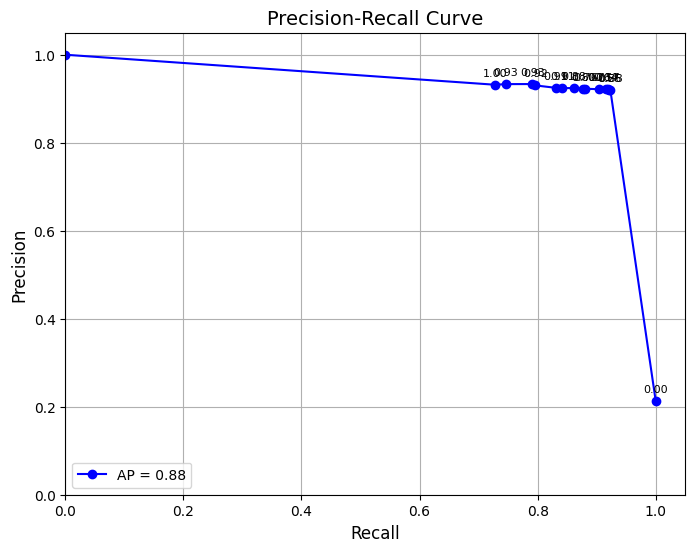

[[2308   55]
 [   3  634]]


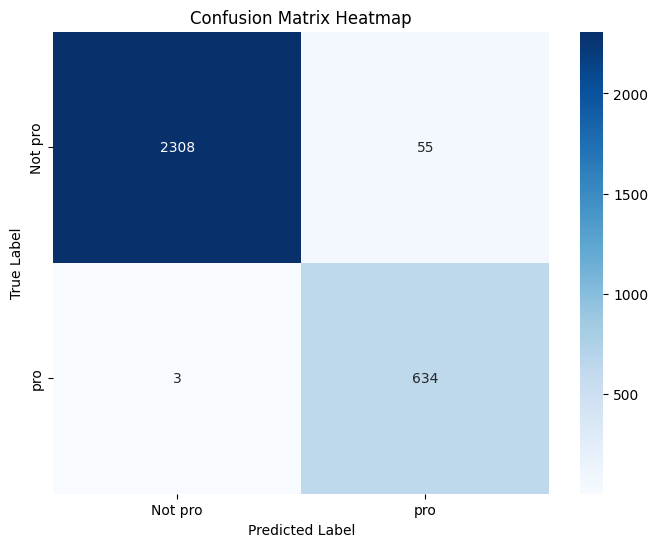

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2363
           1       0.92      1.00      0.96       637

    accuracy                           0.98      3000
   macro avg       0.96      0.99      0.97      3000
weighted avg       0.98      0.98      0.98      3000



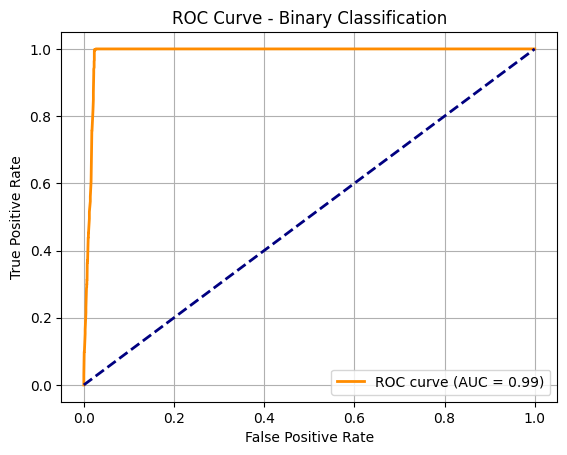

Average Precision (AP): 0.927


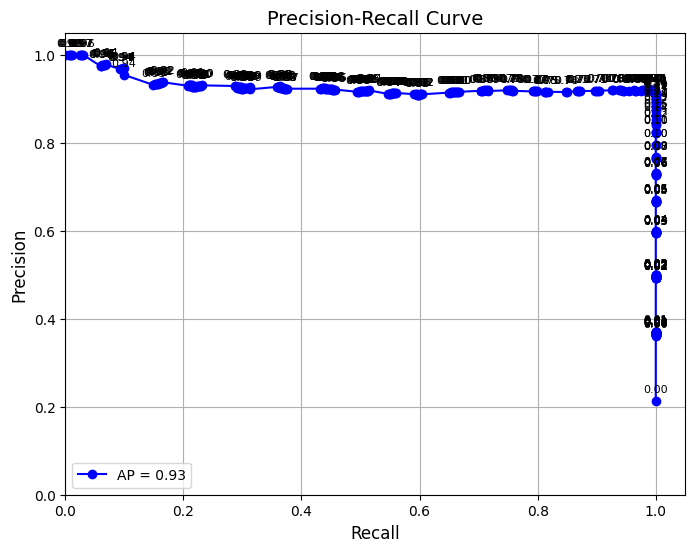

[[2305   58]
 [  99  538]]


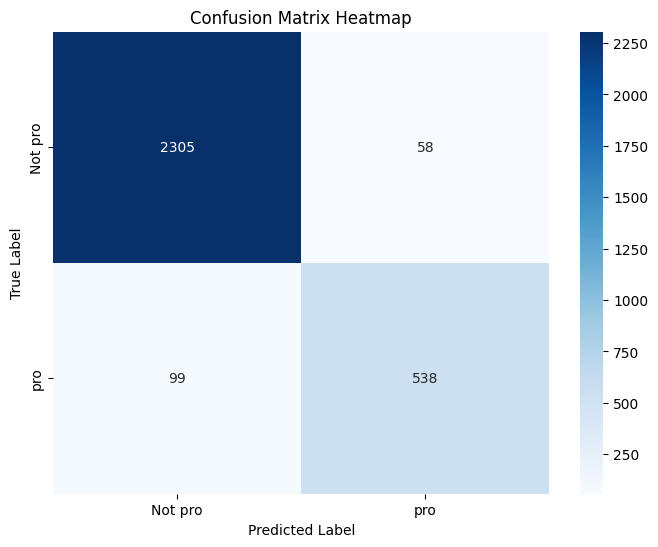

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2363
           1       0.90      0.84      0.87       637

    accuracy                           0.95      3000
   macro avg       0.93      0.91      0.92      3000
weighted avg       0.95      0.95      0.95      3000



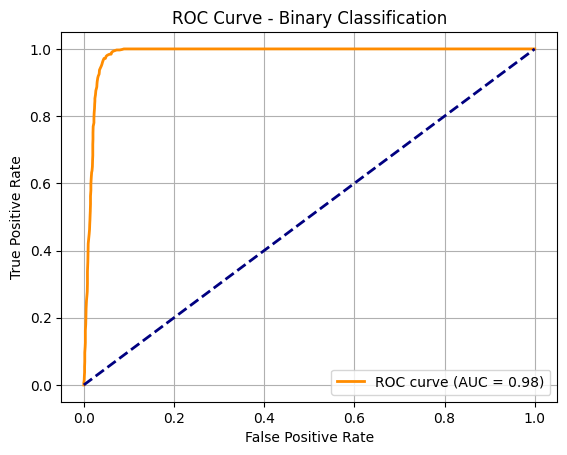

Average Precision (AP): 0.904


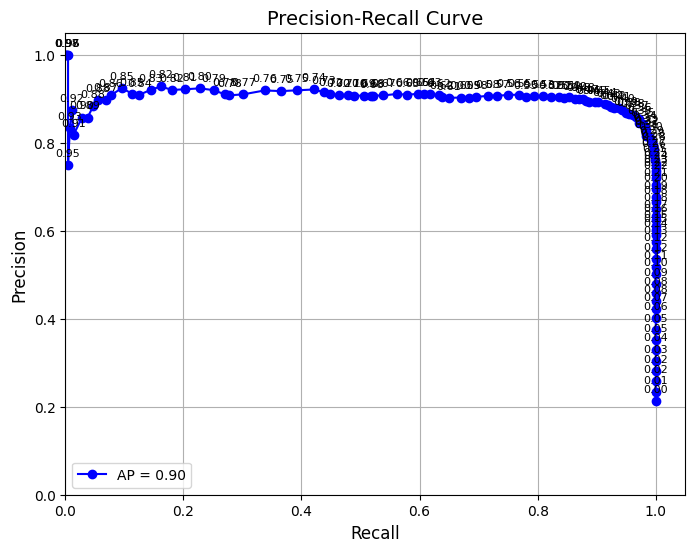

[[2308   55]
 [   1  636]]


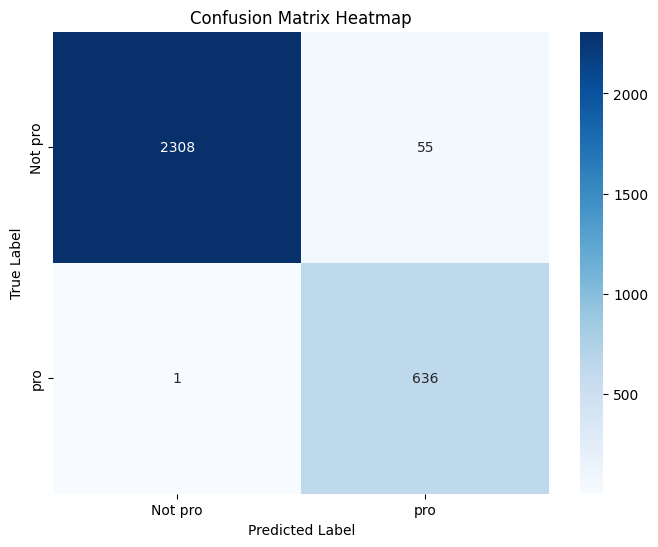

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2363
           1       0.92      1.00      0.96       637

    accuracy                           0.98      3000
   macro avg       0.96      0.99      0.97      3000
weighted avg       0.98      0.98      0.98      3000



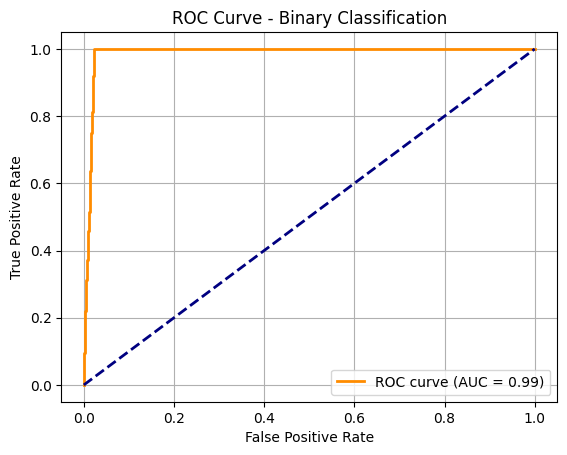

Average Precision (AP): 0.932


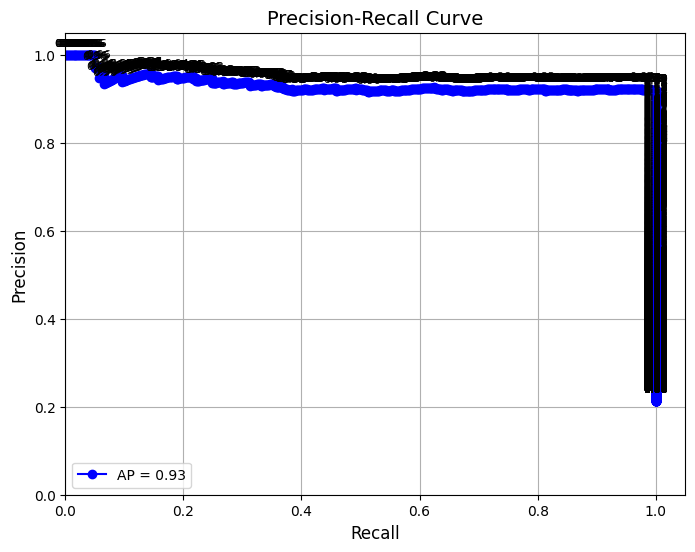

In [71]:
accuracy=[]
for model_name , model in models.items():
    model.fit(X_train_selected,y_train)
    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    Acc_Train = accuracy_score(y_train,y_pred_train)
    Acc_Test  =  accuracy_score(y_test,y_pred_test)


    Pre_Train = precision_score(y_train,y_pred_train)
    Pre_Test  =  precision_score(y_test,y_pred_test)

    Rec_Train = recall_score(y_train,y_pred_train)
    Rec_Test  =  recall_score(y_test,y_pred_test)

    F1_Train = f1_score(y_train,y_pred_train)
    F1_Test  =  f1_score(y_test,y_pred_test)

    accuracy.append([Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test])
    class_names=['Not pro','pro']
    cm = confusion_matrix(y_test,y_pred_test)
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix Heatmap')
    plt.show()
    print(classification_report(y_test,y_pred_test))
    y_probs = model.predict_proba(X_test_selected)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Binary Classification')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


    y_pred_prob = model.predict_proba(X_test_selected)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    ap = average_precision_score(y_test, y_pred_prob)
    print(f"Average Precision (AP): {ap:.3f}")

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='o', color='blue', label=f'AP = {ap:.2f}')

    for r, p, t in zip(recall, precision, list(thresholds) + [None]):
        if t is not None:
            plt.text(r, p + 0.02, f'{t:.2f}', fontsize=8, ha='center')

    plt.title('Precision-Recall Curve', fontsize=14)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.grid(True)
    plt.legend(loc='lower left')
    plt.show()

In [72]:
pd.DataFrame(accuracy,columns=["Acc_Train","Pre_Train","Rec_Train","F1_Train",
                               "Acc_Test","Pre_Test","Rec_Test","F1_Test"],index=models.keys())

,Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test
logistic regression,0.909667,0.802311,0.762652,0.781979,0.907000,0.790584,0.764521,0.777334
GaussianNB,0.903750,0.748573,0.823460,0.784233,0.901000,0.741477,0.819466,0.778523
BernoulliNB,0.823583,0.654506,0.358964,0.463643,0.824667,0.662757,0.354788,0.462168
knn,0.929833,0.880857,0.774421,0.824217,0.885333,0.794769,0.620094,0.696649
svm,0.910833,0.797107,0.778344,0.787614,0.910667,0.793323,0.783359,0.788310
Decision Tree,0.992417,0.966945,0.998431,0.982436,0.966333,0.920063,0.921507,0.920784
Random Forest,1.000000,1.000000,1.000000,1.000000,0.980667,0.920174,0.995290,0.956259
ExtraTrees,1.000000,1.000000,1.000000,1.000000,0.947667,0.902685,0.844584,0.872668
CatBoost,0.977667,0.907758,0.996077,0.949869,0.981333,0.920405,0.998430,0.957831


## show data is balanced or unbalanced

In [73]:
from sklearn.metrics import balanced_accuracy_score
balance=balanced_accuracy_score(y_test,y_pred_test)
balance

np.float64(0.9875773220190124)

In [74]:
df['promotion'].value_counts()

,count
promotion,
0,11814
1,3186


## models use class weight
## LogisticRegression
## SVC
##DecisionTreeClassifier
## RandomForestClassifier
##ExtraTreesClassifier

##**balance data by class weight**

In [75]:
models={
    "logistic regression":LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "GaussianNB":GaussianNB(),
    "BernoulliNB":BernoulliNB(),
    "knn" : KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=1),
    "svm":SVC(kernel="linear",C=150,gamma=5,probability=True,class_weight='balanced'),
    "Decision Tree":DecisionTreeClassifier(criterion='entropy',max_depth=15,class_weight='balanced',random_state=42),
    "Random Forest":RandomForestClassifier(n_estimators=70,criterion='entropy',max_depth=20,class_weight='balanced',random_state=42),
   # "ExtraTrees": ExtraTreesClassifier(n_estimators=130, random_state=42,class_weight='balanced'),
   # "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',max_depth=10,class_weight='balanced'),n_estimators=50, random_state=42),
   #  "ada bosting":AdaBoostClassifier(n_estimators=60,random_state=42),
   # "Gradient boosting":GradientBoostingClassifier(n_estimators=60,learning_rate=0.1,random_state=42),
   # "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42),
   # "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    #"LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

[[2086  277]
 [  46  591]]


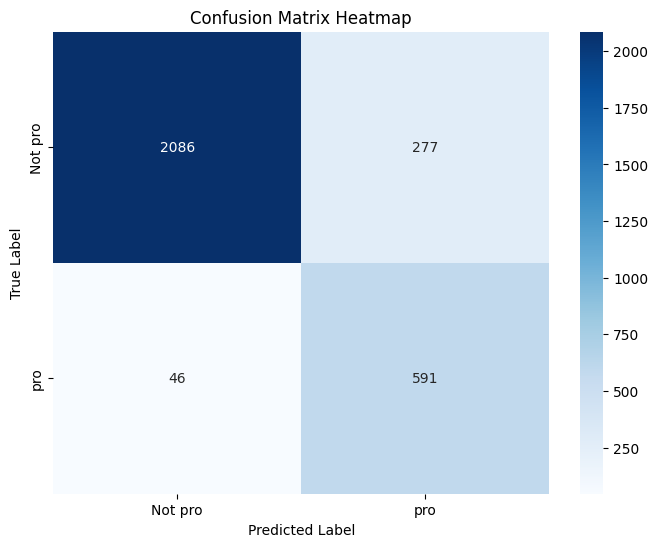

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      2363
           1       0.68      0.93      0.79       637

    accuracy                           0.89      3000
   macro avg       0.83      0.91      0.86      3000
weighted avg       0.92      0.89      0.90      3000



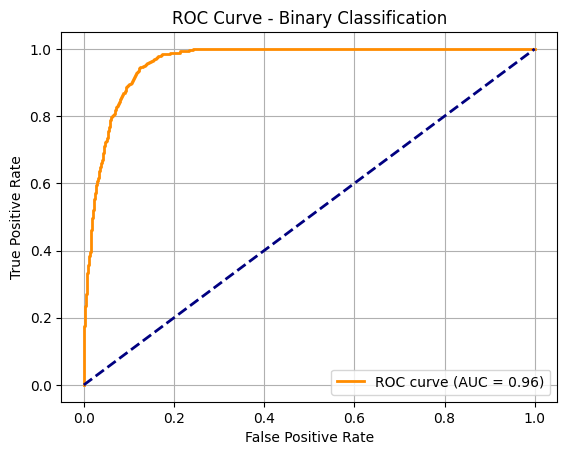

Average Precision (AP): 0.854


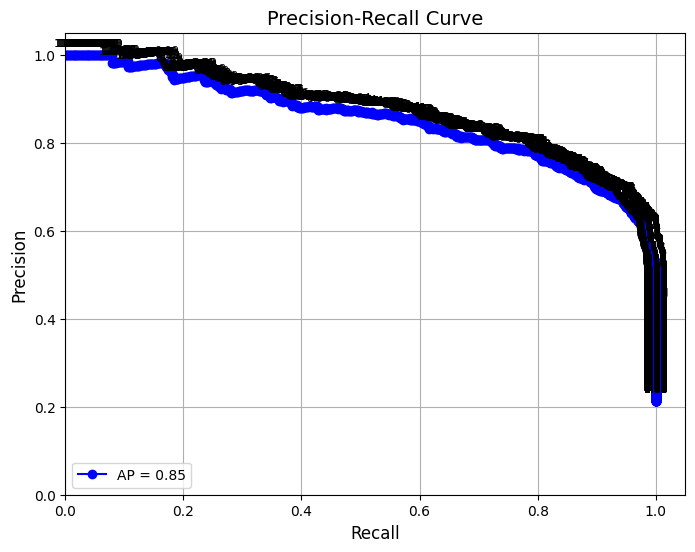

[[2181  182]
 [ 115  522]]


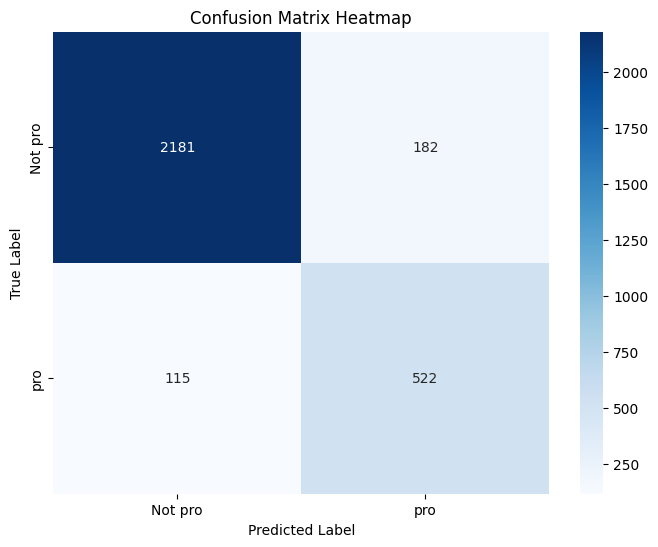

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      2363
           1       0.74      0.82      0.78       637

    accuracy                           0.90      3000
   macro avg       0.85      0.87      0.86      3000
weighted avg       0.91      0.90      0.90      3000



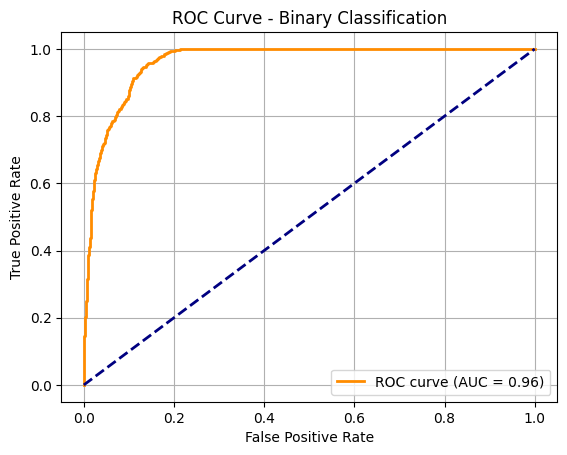

Average Precision (AP): 0.857


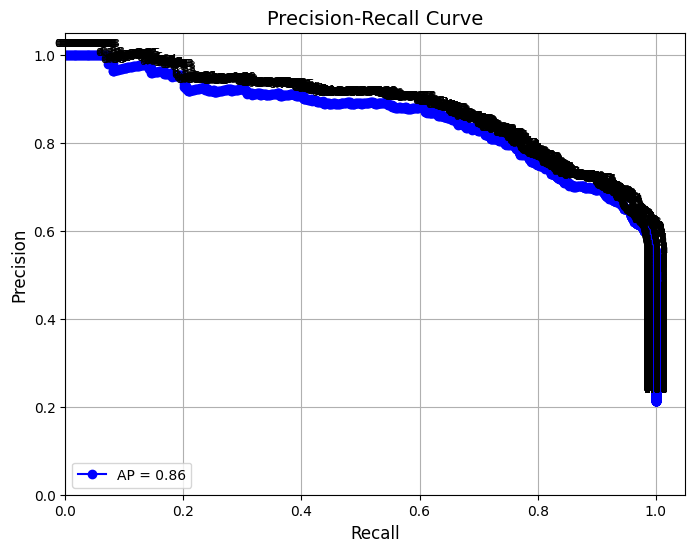

[[2248  115]
 [ 411  226]]


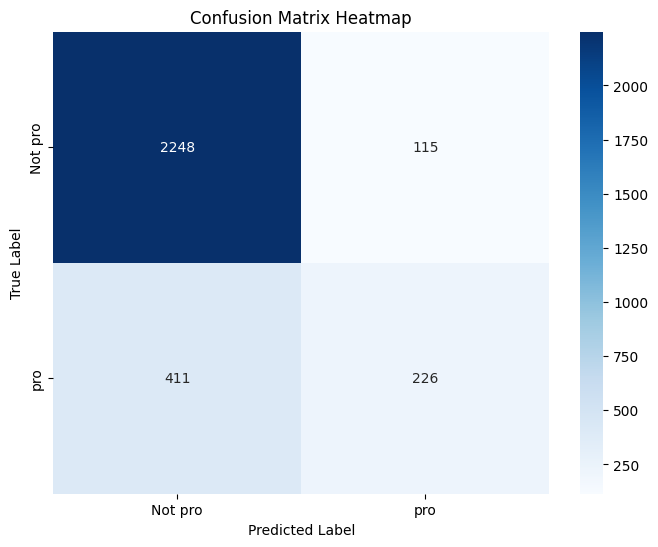

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2363
           1       0.66      0.35      0.46       637

    accuracy                           0.82      3000
   macro avg       0.75      0.65      0.68      3000
weighted avg       0.81      0.82      0.80      3000



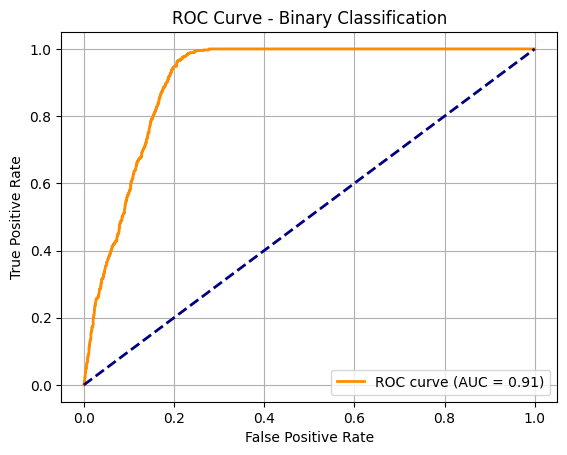

Average Precision (AP): 0.633


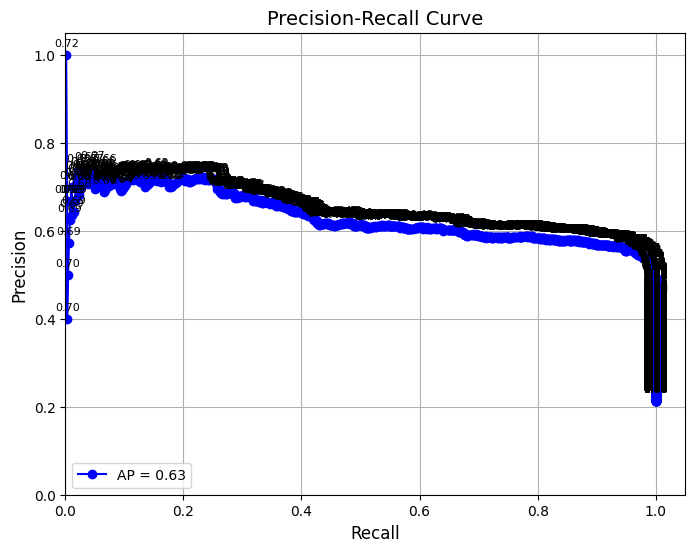

[[2261  102]
 [ 242  395]]


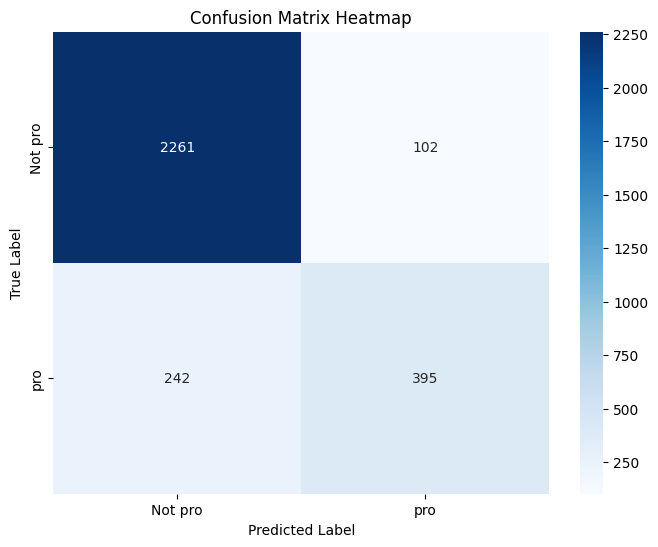

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      2363
           1       0.79      0.62      0.70       637

    accuracy                           0.89      3000
   macro avg       0.85      0.79      0.81      3000
weighted avg       0.88      0.89      0.88      3000



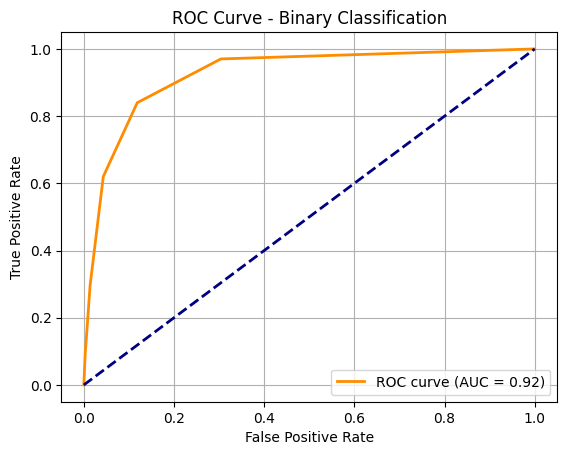

Average Precision (AP): 0.724


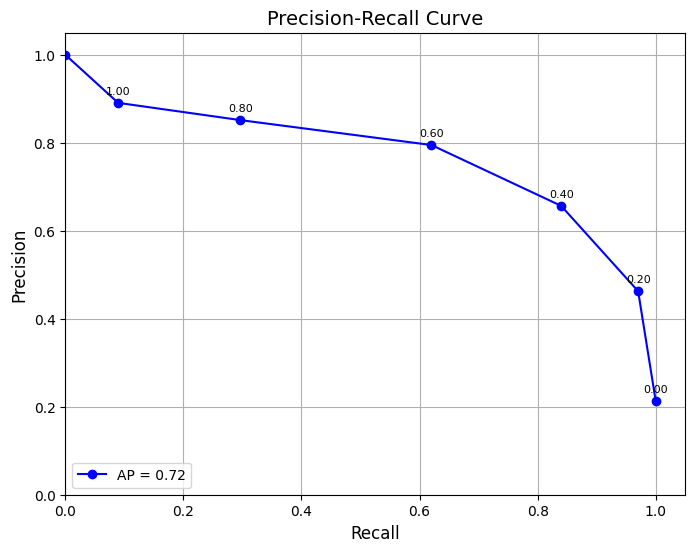

[[2066  297]
 [  36  601]]


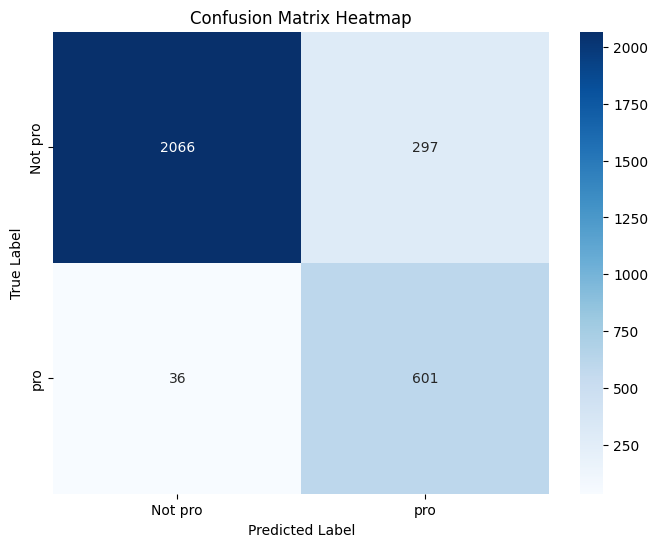

              precision    recall  f1-score   support

           0       0.98      0.87      0.93      2363
           1       0.67      0.94      0.78       637

    accuracy                           0.89      3000
   macro avg       0.83      0.91      0.85      3000
weighted avg       0.92      0.89      0.90      3000



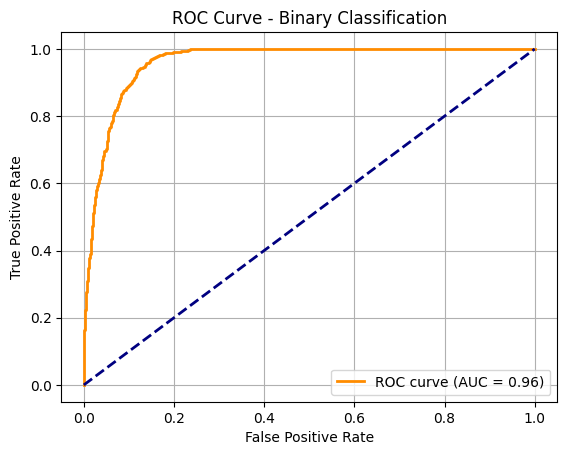

Average Precision (AP): 0.850


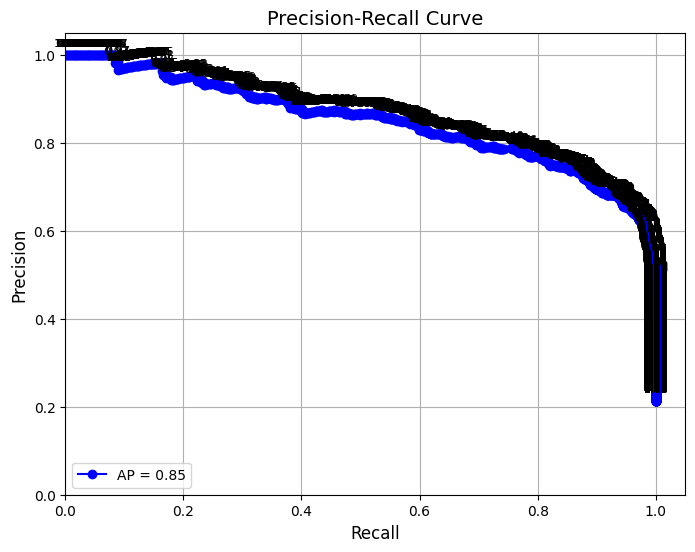

[[2312   51]
 [  32  605]]


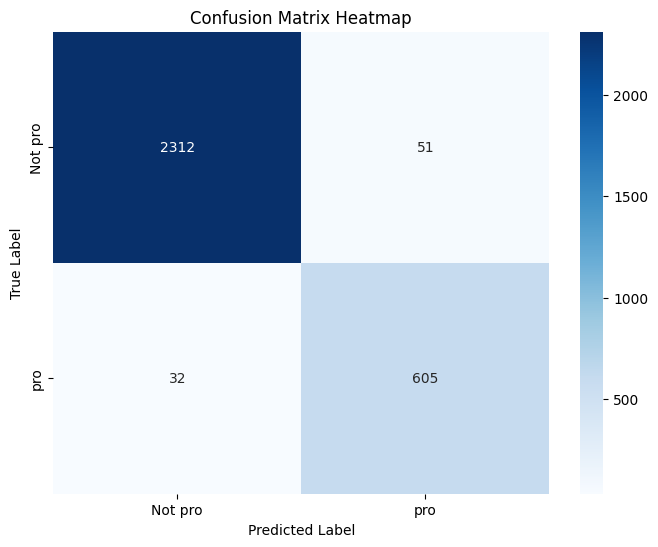

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2363
           1       0.92      0.95      0.94       637

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



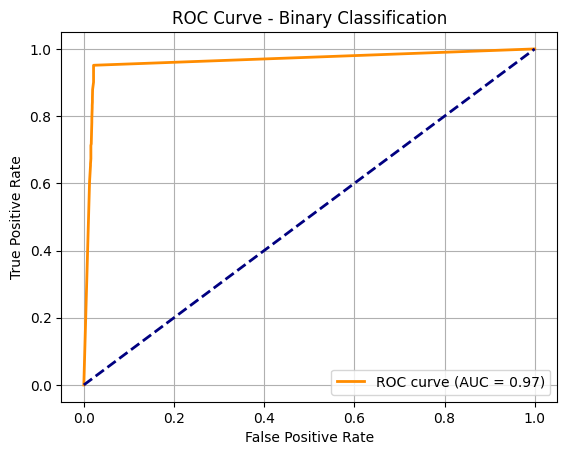

Average Precision (AP): 0.891


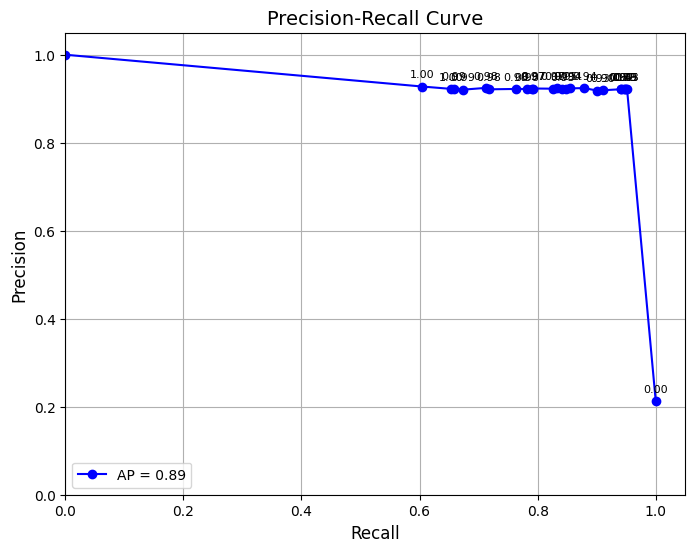

[[2308   55]
 [   3  634]]


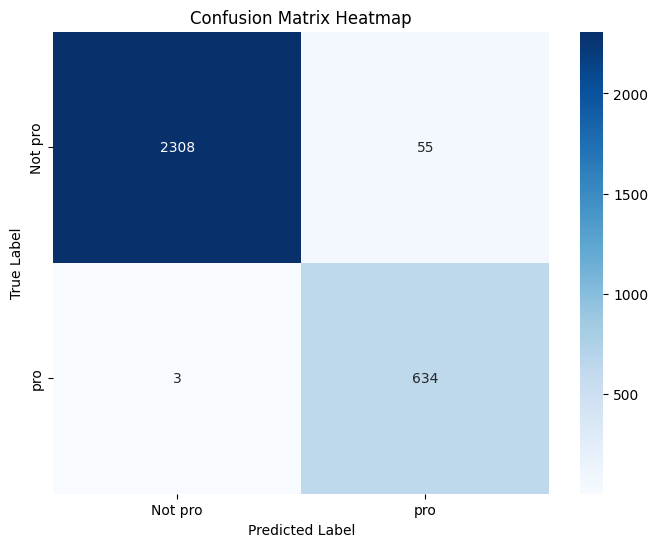

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2363
           1       0.92      1.00      0.96       637

    accuracy                           0.98      3000
   macro avg       0.96      0.99      0.97      3000
weighted avg       0.98      0.98      0.98      3000



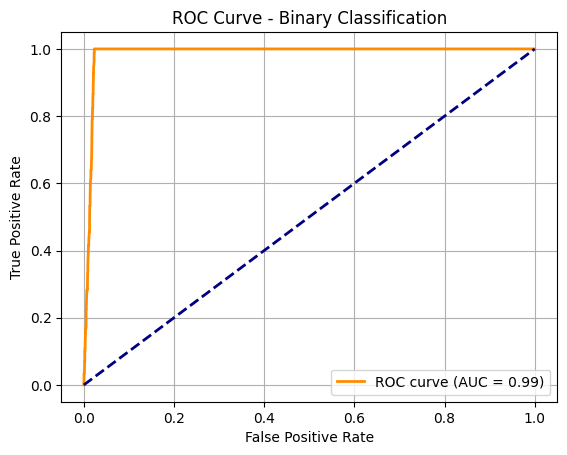

Average Precision (AP): 0.917


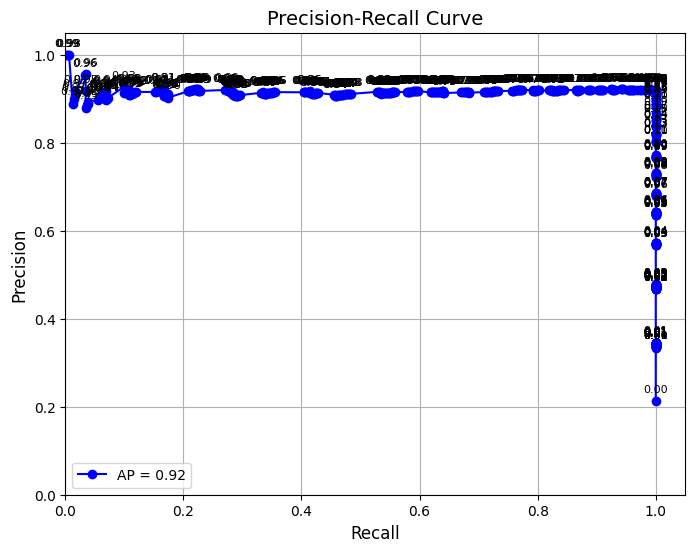

[[2308   55]
 [   1  636]]


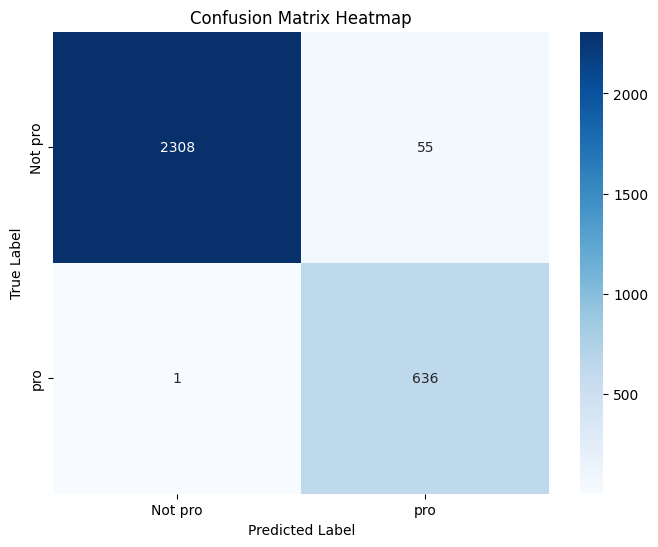

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2363
           1       0.92      1.00      0.96       637

    accuracy                           0.98      3000
   macro avg       0.96      0.99      0.97      3000
weighted avg       0.98      0.98      0.98      3000



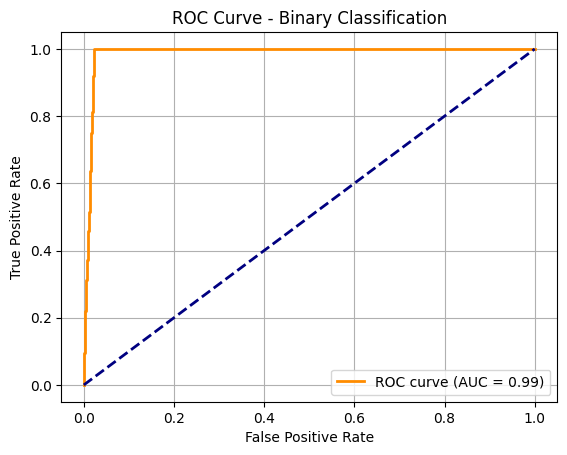

Average Precision (AP): 0.932


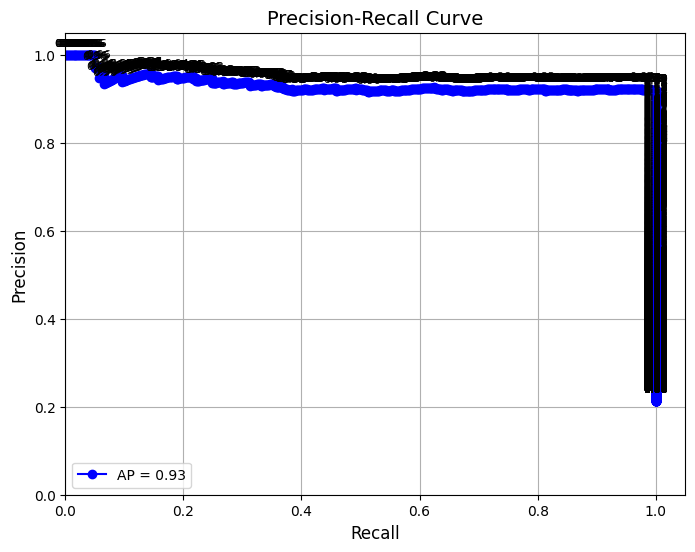

In [76]:
accuracy=[]
for model_name , model in models.items():
    model.fit(X_train_selected,y_train)
    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    Acc_Train = accuracy_score(y_train,y_pred_train)
    Acc_Test  =  accuracy_score(y_test,y_pred_test)


    Pre_Train = precision_score(y_train,y_pred_train)
    Pre_Test  =  precision_score(y_test,y_pred_test)

    Rec_Train = recall_score(y_train,y_pred_train)
    Rec_Test  =  recall_score(y_test,y_pred_test)

    F1_Train = f1_score(y_train,y_pred_train)
    F1_Test  =  f1_score(y_test,y_pred_test)

    accuracy.append([Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test])
    class_names=['Not pro','pro']
    cm = confusion_matrix(y_test,y_pred_test)
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix Heatmap')
    plt.show()
    print(classification_report(y_test,y_pred_test))
    y_probs = model.predict_proba(X_test_selected)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Binary Classification')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


    y_pred_prob = model.predict_proba(X_test_selected)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    ap = average_precision_score(y_test, y_pred_prob)
    print(f"Average Precision (AP): {ap:.3f}")

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='o', color='blue', label=f'AP = {ap:.2f}')

    for r, p, t in zip(recall, precision, list(thresholds) + [None]):
        if t is not None:
            plt.text(r, p + 0.02, f'{t:.2f}', fontsize=8, ha='center')

    plt.title('Precision-Recall Curve', fontsize=14)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.grid(True)
    plt.legend(loc='lower left')
    plt.show()

In [77]:

pd.DataFrame(accuracy,columns=["Acc_Train","Pre_Train","Rec_Train","F1_Train",
                               "Acc_Test","Pre_Test","Rec_Test","F1_Test"],index=models.keys())

,Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test
logistic regression,0.890000,0.675021,0.929776,0.782178,0.892333,0.680876,0.927786,0.785382
GaussianNB,0.903750,0.748573,0.823460,0.784233,0.901000,0.741477,0.819466,0.778523
BernoulliNB,0.823583,0.654506,0.358964,0.463643,0.824667,0.662757,0.354788,0.462168
knn,0.929833,0.880857,0.774421,0.824217,0.885333,0.794769,0.620094,0.696649
svm,0.886833,0.663554,0.947823,0.780614,0.889000,0.669265,0.943485,0.783062
Decision Tree,0.990250,0.956456,0.999608,0.977556,0.972333,0.922256,0.949765,0.935808
Random Forest,0.999833,0.999216,1.000000,0.999608,0.980667,0.920174,0.995290,0.956259
CatBoost,0.977667,0.907758,0.996077,0.949869,0.981333,0.920405,0.998430,0.957831


## random search
##to find
##1-best parameters
##2-best score

In [79]:
#from sklearn.model_selection import RandomizedSearchCV

#model = GradientBoostingClassifier()

#param_distributions = {
 #   'n_estimators': np.arange(10,61),
  #  'max_depth': np.arange(10,50)
#}

#random_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions, n_iter=50, cv=5, scoring='accuracy')

#random_search.fit(X_train_selected,y_train)

#best_params = random_search.best_params_
#print("Best Parameters:", best_params)


In [78]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
import numpy as np
import pickle

model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

param_distributions = {
    'iterations': np.arange(100, 150, 50),
    'depth': np.arange(4, 15),
    'learning_rate': np.linspace(0.01, 0.3, 30)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 🔥 التدريب
random_search.fit(X_train_selected, y_train)

# -----------------------------
# أفضل موديل + نتائج
# -----------------------------
best_model = random_search.best_estimator_

best_params = random_search.best_params_
best_score = random_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

# -----------------------------
# 🔥 حفظ الموديل الصح
# -----------------------------
pickle.dump(best_model, open("catBoostingClassifier.pkl", "wb"))


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Best Parameters: {'learning_rate': np.float64(0.16999999999999998), 'iterations': np.int64(100), 'depth': np.int64(5)}
Best Score: 0.9774166666666666
